In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import randint
import optuna

In [3]:
# Import the dataset and see the basic information about it
df = pd.read_csv("/kaggle/input/car-price-prediction-dataset/cardekho.csv")
df.drop(columns=['name'], inplace=True)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

   year  selling_price  km_driven    fuel seller_type transmission  \
0  2014         450000     145500  Diesel  Individual       Manual   
1  2014         370000     120000  Diesel  Individual       Manual   
2  2006         158000     140000  Petrol  Individual       Manual   
3  2010         225000     127000  Diesel  Individual       Manual   
4  2007         130000     120000  Petrol  Individual       Manual   

          owner  mileage(km/ltr/kg)  engine max_power  seats  
0   First Owner               23.40  1248.0        74    5.0  
1  Second Owner               21.14  1498.0    103.52    5.0  
2   Third Owner               17.70  1497.0        78    5.0  
3   First Owner               23.00  1396.0        90    5.0  
4   First Owner               16.10  1298.0      88.2    5.0  
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                

In [4]:
# Create a duplicate dataframe for data manipulations and building a model
df_original = df.copy()
df_copy = df.copy()
print("Data copied to df_copy successfully!")

Data copied to df_copy successfully!


In [5]:
df_copy['max_power'] = df['max_power'].str.replace('bhp', '', regex=False).str.strip()
df_copy['max_power'] = df['max_power'].replace('-', np.nan)
df_copy['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

In [6]:
# Fill missing numeric values with mean
df_copy['max_power'].fillna(df_copy['max_power'].mean(), inplace=True)
df_copy.fillna(df.mean(numeric_only=True), inplace=True)

In [7]:
# Label encode categorical columns
import pickle

# Saving the encoding parts for advancements in future
encoders = {}

for col in df_copy.columns:
    if df_copy[col].dtype == 'object':
        encoder = LabelEncoder()
        df_copy[col] = encoder.fit_transform(df_copy[col])
        encoders[col] = encoder

# Save the encoders part
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Encoders dumped successfully!")

Encoders dumped successfully!


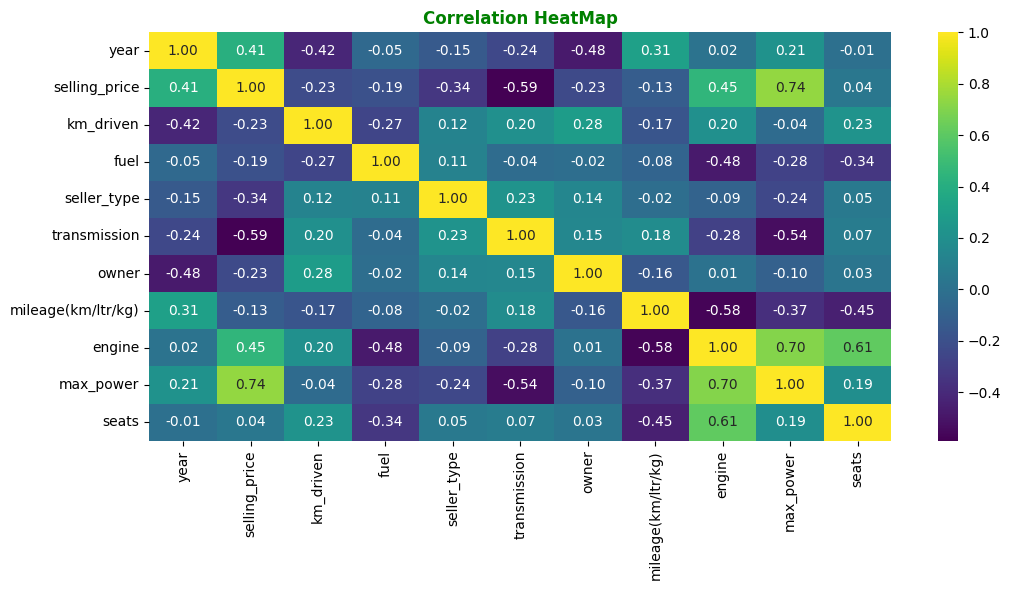

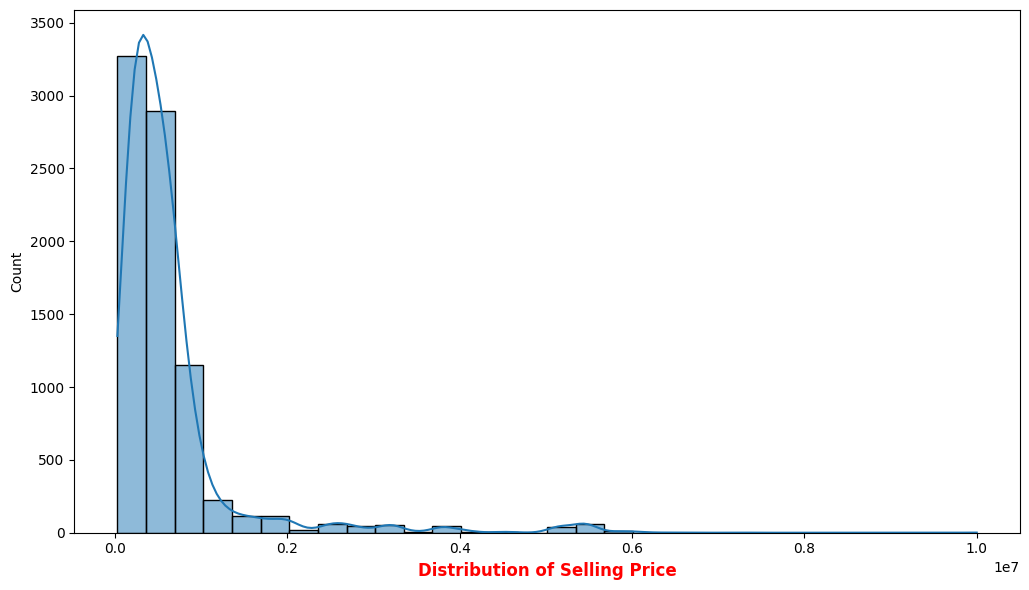

In [8]:
# Correlation map
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
sns.heatmap(df_copy.corr(), annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation HeatMap", color='green', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribution Table of Close
plt.figure(figsize=(20,6))
plt.subplot(1,2,2)
sns.histplot(df_copy['selling_price'], kde=True, bins=30)
plt.xlabel("Distribution of Selling Price", color='red', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Split features & target
X = df_copy.drop(columns=['selling_price'])
y = df_copy['selling_price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))

In [11]:
import optuna
from sklearn.model_selection import cross_val_score
import numpy as np

# Objective function for Optuna
def objective(trial):
    # Define the parameter search space
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['log2', 'sqrt'])
    }

    model = RandomForestRegressor(random_state=42, **params)
    
    # Perform 5-fold cross-validation and return mean R² score
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    return np.mean(score)

# Create and run the Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Best parameters and best score
print("\nBest Optuna Params:", study.best_params)
print("Best Optuna R² Score (CV):", study.best_value)

# Train the final model using the best parameters
best_optuna_model = RandomForestRegressor(random_state=42, **study.best_params)
best_optuna_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_optuna = best_optuna_model.predict(X_test_scaled)
evaluate_model("Optuna Optimization", y_test, y_pred_optuna)

[I 2025-10-30 16:30:09,730] A new study created in memory with name: no-name-c26a1881-d655-46f4-8194-e7fcf81f748f


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-10-30 16:30:14,394] Trial 0 finished with value: 0.9414593799539157 and parameters: {'n_estimators': 183, 'max_depth': 45, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.9414593799539157.
[I 2025-10-30 16:30:15,796] Trial 1 finished with value: 0.9395275552779545 and parameters: {'n_estimators': 108, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 0.9414593799539157.
[I 2025-10-30 16:30:19,362] Trial 2 finished with value: 0.9465690922364132 and parameters: {'n_estimators': 255, 'max_depth': 31, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.9465690922364132.
[I 2025-10-30 16:30:28,353] Trial 3 finished with value: 0.9599460249387854 and parameters: {'n_estimators': 434, 'max_depth': 34, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 3 with value: 0.95994602493878

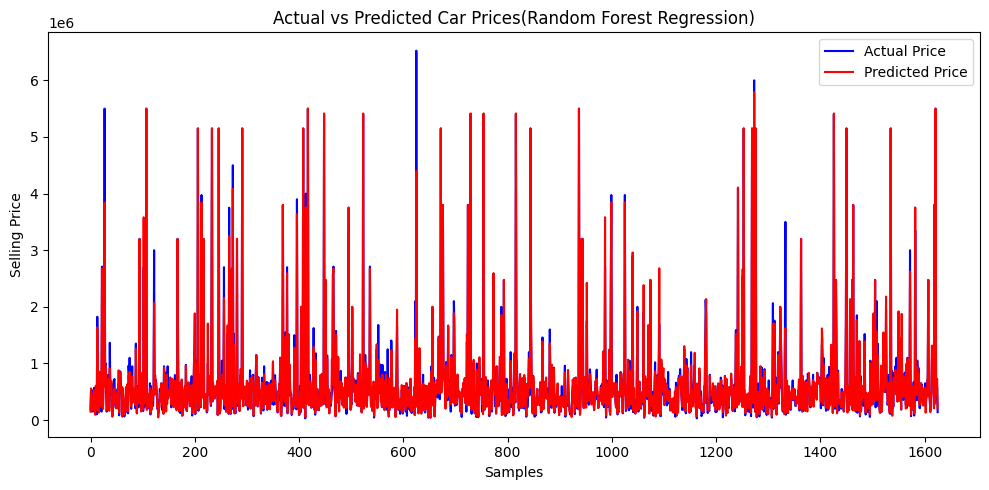

In [25]:
# Plot for the actual vs predicted

plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual Price', color='blue')
plt.plot(y_pred_optuna, label='Predicted Price', color='red')
plt.title('Actual vs Predicted Car Prices(Random Forest Regression)')
plt.xlabel('Samples')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.legend()
plt.show()

In [16]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_parallel_coordinate,
    plot_contour,
    plot_edf
)

# Basic summary
best_params = study.best_params
best_score = study.best_value

print("Best Parameters:", best_params)
print("Best CV R² Score:", best_score)

# Generate and save PNG plots
plots = {
    "optimization_history": plot_optimization_history(study),
    "param_importances": plot_param_importances(study),
    "parallel_coordinate": plot_parallel_coordinate(study),
    "contour": plot_contour(study),
    "slice": plot_slice(study),
    "edf": plot_edf(study)
}

# Show and save plots
for name, fig in plots.items():
    fig.show()

Best Parameters: {'n_estimators': 461, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best CV R² Score: 0.9601783952475105


In [12]:
from sklearn.pipeline import make_pipeline
import joblib

# Create pipeline
pipe = make_pipeline(StandardScaler(), best_optuna_model)
pipe.fit(X_train, y_train)

# Save
joblib.dump(pipe, "/kaggle/working/random_forest_pipeline.pkl")
print("Model saved successfully!")

Model saved successfully!


In [13]:
df_original.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pickle

# Load encoders only
with open("encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

# --- Train the scaler manually using your training data ---
# Make sure X_train is defined from your model training step
scaler = StandardScaler()
scaler.fit(X_train)   # use your existing training data

# Example new user input
new_data = {
    'year': [2014, 2014, 2006, 2010, 2007],
    'km_driven': [145500, 120000, 140000, 127000, 120000],
    'fuel': ['Diesel', 'Diesel', 'Petrol', 'Diesel', 'Petrol'],
    'seller_type': ['Individual', 'Individual', 'Individual', 'Individual', 'Individual'],
    'transmission': ['Manual', 'Manual', 'Manual', 'Manual', 'Manual'],
    'owner': ['First Owner', 'Second Owner', 'Third Owner', 'First Owner', 'First Owner'],
    'mileage(km/ltr/kg)': [23.40, 21.14, 17.70, 23.00, 16.10],
    'engine': [1248.0, 1498.0, 1497.0, 1396.0, 1298.0],
    'max_power': [74.0, 103.52, 78.0, 90.0, 88.2],
    'seats': [5.0, 5.0, 5.0, 5.0, 5.0]
}

# Convert to DataFrame
new_df = pd.DataFrame(new_data)

# Encode categorical features using loaded encoders
for col, encoder in encoders.items():
    if col in new_df.columns:
        new_df[col] = new_df[col].map(lambda x: encoder.transform([x])[0] if x in encoder.classes_ else -1)

# Reorder columns same as training data
new_df = new_df[X_train.columns]

# Scale using manually trained scaler
new_df_scaled = scaler.transform(new_df)

# Predict using your trained model (Optuna tuned model)
predicted_price = best_optuna_model.predict(new_df_scaled)
print("Predicted Selling Prices:", np.round(predicted_price, 2))

Predicted Selling Prices: [469605.85 468112.37 165871.4  278537.29 164307.73]
